# 📊 Phase 2 — EDA : Exploration et Analyse des Données

**Objectif de ce notebook :**
- Profiler en détail les données réelles (`FACT_ACTIVITE`)
- Détecter valeurs manquantes, anomalies, outliers
- Comprendre les distributions et patterns business
- Formuler des hypothèses pour les modèles ML

---
> 💡 **Pré-requis :** Avoir exécuté Phase 1 pour avoir le fichier `data/raw/fact_activite.csv`

## 🔧 Étape 1 — Chargement des données

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='husl')

# --- Charger les données depuis CSV (sauvegardé en Phase 1) ---
CSV_PATH = r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\raw\fact_activite.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
    print(f'✅ Données chargées depuis CSV : {df.shape[0]} lignes × {df.shape[1]} colonnes')
else:
    print('⚠️ CSV non trouvé. Connexion directe SQL Server...')
    from sqlalchemy import create_engine, text
    import urllib
    conn_str = (
        'DRIVER={ODBC Driver 17 for SQL Server};'
        'SERVER=GEORGE\\MSSQLSERVER03;'
        'DATABASE=DWH_ARTISANAT;'
        'Trusted_Connection=yes;'
    )
    params = urllib.parse.quote_plus(conn_str)
    engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')
    query = """
    SELECT fa.*, dd.Annee, dd.Mois, dd.Trimestre, dd.Lib_Mois
    FROM FACT_ACTIVITE fa
    LEFT JOIN DIM_DATE dd ON fa.FK_DATE = dd.DATE_PK
    ORDER BY dd.Annee DESC, dd.Mois DESC
    """
    df = pd.read_sql(query, engine)
    print(f'✅ Données chargées depuis SQL : {df.shape[0]} lignes × {df.shape[1]} colonnes')

print('\nAperçu :')
display(df.head(3))

✅ Données chargées depuis CSV : 659 lignes × 23 colonnes

Aperçu :


,FK_Produit,FK_Client,FK_Date,FK_Geographie,FK_Fournisseur,FK_Concurrent,FK_SocialMedia,FK_Document,FK_Commande,FK_Type,...,Montant_TVA,Montant_TTC,Remise,Prix_concurrent,Likes,Commentaires,Annee,Mois,Trimestre,Lib_Mois
0,-1,237,20260304,-1,-1,-1,-1,290,-1,1,...,0.0,179.500000,0.0,0.0,0,0,2026,3,T1,March
1,-1,3,20260312,-1,-1,-1,-1,308,-1,1,...,0.0,17.365927,0.0,0.0,0,0,2026,3,T1,March
2,-1,-1,20260204,-1,-1,-1,8,-1,-1,3,...,0.0,0.000000,0.0,0.0,12,0,2026,2,T1,February


---
## 🔍 Étape 2 — Profil général du dataset

Comprendre la structure + types de données avant d'aller plus loin.

In [3]:
print('=== INFORMATIONS GÉNÉRALES ===')
print(f'Nombre de lignes    : {df.shape[0]:,}')
print(f'Nombre de colonnes  : {df.shape[1]}')
print(f'Mémoire utilisée    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

print('\n=== TYPES DE COLONNES ===')
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f'  {str(dtype):<12} : {count} colonnes')

print('\n=== DÉTAIL DES COLONNES ===')
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.notna().sum(),
    'Null': df.isna().sum(),
    'Null %': (df.isna().sum() / len(df) * 100).round(1),
    'Unique': df.nunique(),
    'Sample': df.iloc[0]
})
display(info_df)

=== INFORMATIONS GÉNÉRALES ===
Nombre de lignes    : 659
Nombre de colonnes  : 23
Mémoire utilisée    : 185.8 KB

=== TYPES DE COLONNES ===
  int64        : 15 colonnes
  float64      : 6 colonnes
  object       : 2 colonnes

=== DÉTAIL DES COLONNES ===


,Type,Non-Null,Null,Null %,Unique,Sample
FK_Produit,int64,659,0,0.0,32,-1
FK_Client,int64,659,0,0.0,267,237
FK_Date,int64,659,0,0.0,313,20260304
FK_Geographie,int64,659,0,0.0,109,-1
FK_Fournisseur,int64,659,0,0.0,89,-1
FK_Concurrent,int64,659,0,0.0,4,-1
FK_SocialMedia,int64,659,0,0.0,65,-1
FK_Document,int64,659,0,0.0,249,290
FK_Commande,int64,659,0,0.0,256,-1
FK_Type,int64,659,0,0.0,4,1


In [4]:
# Statistiques descriptives pour les colonnes numériques
print('=== STATISTIQUES DESCRIPTIVES ===')
display(df.describe().round(2))

=== STATISTIQUES DESCRIPTIVES ===


,FK_Produit,FK_Client,FK_Date,FK_Geographie,FK_Fournisseur,FK_Concurrent,FK_SocialMedia,FK_Document,FK_Commande,FK_Type,...,Prix_unitaire,Montant_HT,Montant_TVA,Montant_TTC,Remise,Prix_concurrent,Likes,Commentaires,Annee,Mois
count,659.00,659.00,659.00,659.00,659.00,659.00,659.00,659.00,659.00,659.00,...,659.00,659.00,659.00,659.00,659.00,659.00,659.00,659.00,659.00,659.00
mean,16.02,75.44,19602583.27,11.64,10.19,0.13,2.25,69.83,48.92,1.52,...,1331.47,824.92,111.46,975.04,0.38,0.55,2.39,0.09,1960.19,6.27
std,32.22,99.95,3559122.35,25.77,26.35,17.70,11.48,102.88,77.80,0.69,...,26719.72,6136.70,1109.15,7283.73,5.63,13.64,12.36,0.70,355.90,3.94
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,-1.00,-1.00,20241223.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,1.00,...,0.00,8.00,0.00,14.91,0.00,0.00,0.00,0.00,2024.00,3.00
50%,-1.00,6.00,20250310.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,1.00,...,0.00,58.00,0.00,68.98,0.00,0.00,0.00,0.00,2025.00,6.00
75%,15.00,149.50,20250809.50,6.00,-1.00,-1.00,-1.00,149.50,90.50,2.00,...,49.95,168.20,1.25,239.00,0.00,0.00,0.00,0.00,2025.00,10.00
max,112.00,319.00,20260312.00,108.00,110.00,331.00,64.00,312.00,255.00,4.00,...,655830.00,137692.81,25697.73,163390.55,100.00,350.00,239.00,11.00,2026.00,12.00


---
## 🚩 Étape 3 — Analyse des Valeurs Manquantes

Les valeurs manquantes peuvent biaiser les modèles ML. On doit les identifier et décider de la stratégie.

⚠️  2 colonnes avec des valeurs manquantes :


,Count,Percent
Trimestre,21,3.19
Lib_Mois,21,3.19


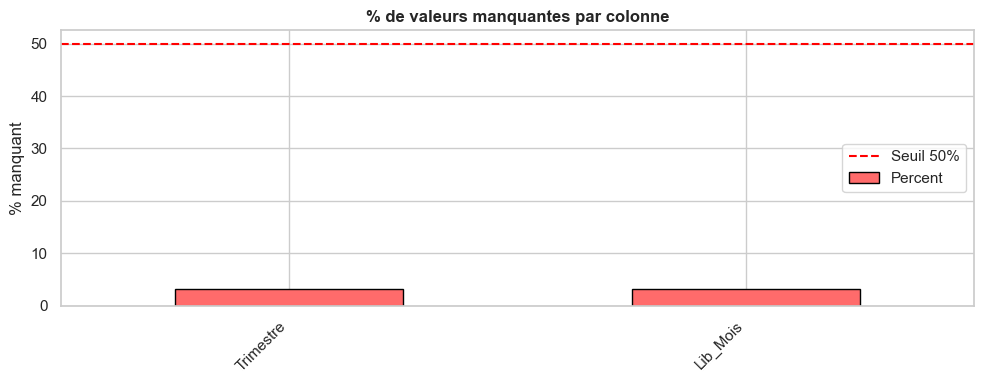

In [5]:
# --- Calcul des manquants ---
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)

if len(missing_df) == 0:
    print('✅ Aucune valeur manquante (NaN) détectée !')
    print('\n📌 Note : Vérifier aussi les valeurs sentinelles (-1 = inconnu dans un Data Warehouse)')
else:
    print(f'⚠️  {len(missing_df)} colonnes avec des valeurs manquantes :')
    display(missing_df)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Percent'].plot(kind='bar', ax=ax, color='#FF6B6B', edgecolor='black')
    ax.set_title('% de valeurs manquantes par colonne', fontweight='bold')
    ax.set_ylabel('% manquant')
    ax.axhline(y=50, color='red', linestyle='--', label='Seuil 50%')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [6]:
# --- Analyse des valeurs sentinelles (-1 = inconnu dans un DWH) ---
print('=== VALEURS SENTINELLES (-1 = inconnu dans ce Data Warehouse) ===')
fk_cols = [c for c in df.columns if c.startswith('FK_')]
print(f'\nColonnes FK détectées : {fk_cols}')
print()

sentinel_stats = []
for col in fk_cols:
    n_sentinels = (df[col] == -1).sum()
    pct = n_sentinels / len(df) * 100
    sentinel_stats.append({'Colonne': col, 'Valeur=-1': n_sentinels, '%': round(pct, 1)})

sentinel_df = pd.DataFrame(sentinel_stats).sort_values('%', ascending=False)
display(sentinel_df)

print('\n📌 Interprétation :')
print('  - FK avec beaucoup de -1 → dimension pas toujours applicable')
print('  - Ex: FK_SocialMedia = -1 pour les ventes non liées aux réseaux sociaux')

=== VALEURS SENTINELLES (-1 = inconnu dans ce Data Warehouse) ===

Colonnes FK détectées : ['FK_Produit', 'FK_Client', 'FK_Date', 'FK_Geographie', 'FK_Fournisseur', 'FK_Concurrent', 'FK_SocialMedia', 'FK_Document', 'FK_Commande', 'FK_Type']



,Colonne,Valeur=-1,%
5,FK_Concurrent,656,99.5
6,FK_SocialMedia,595,90.3
4,FK_Fournisseur,509,77.2
0,FK_Produit,486,73.7
3,FK_Geographie,426,64.6
8,FK_Commande,404,61.3
7,FK_Document,390,59.2
1,FK_Client,310,47.0
2,FK_Date,21,3.2
9,FK_Type,0,0.0



📌 Interprétation :
  - FK avec beaucoup de -1 → dimension pas toujours applicable
  - Ex: FK_SocialMedia = -1 pour les ventes non liées aux réseaux sociaux


---
## 📈 Étape 4 — Distribution des Variables Numériques

Comprendre comment sont distribuées les valeurs → détection d'outliers, skewness.

Colonnes numériques analysées : ['Quantite', 'Prix_unitaire', 'Montant_HT', 'Montant_TVA', 'Montant_TTC', 'Remise', 'Prix_concurrent', 'Likes', 'Commentaires']


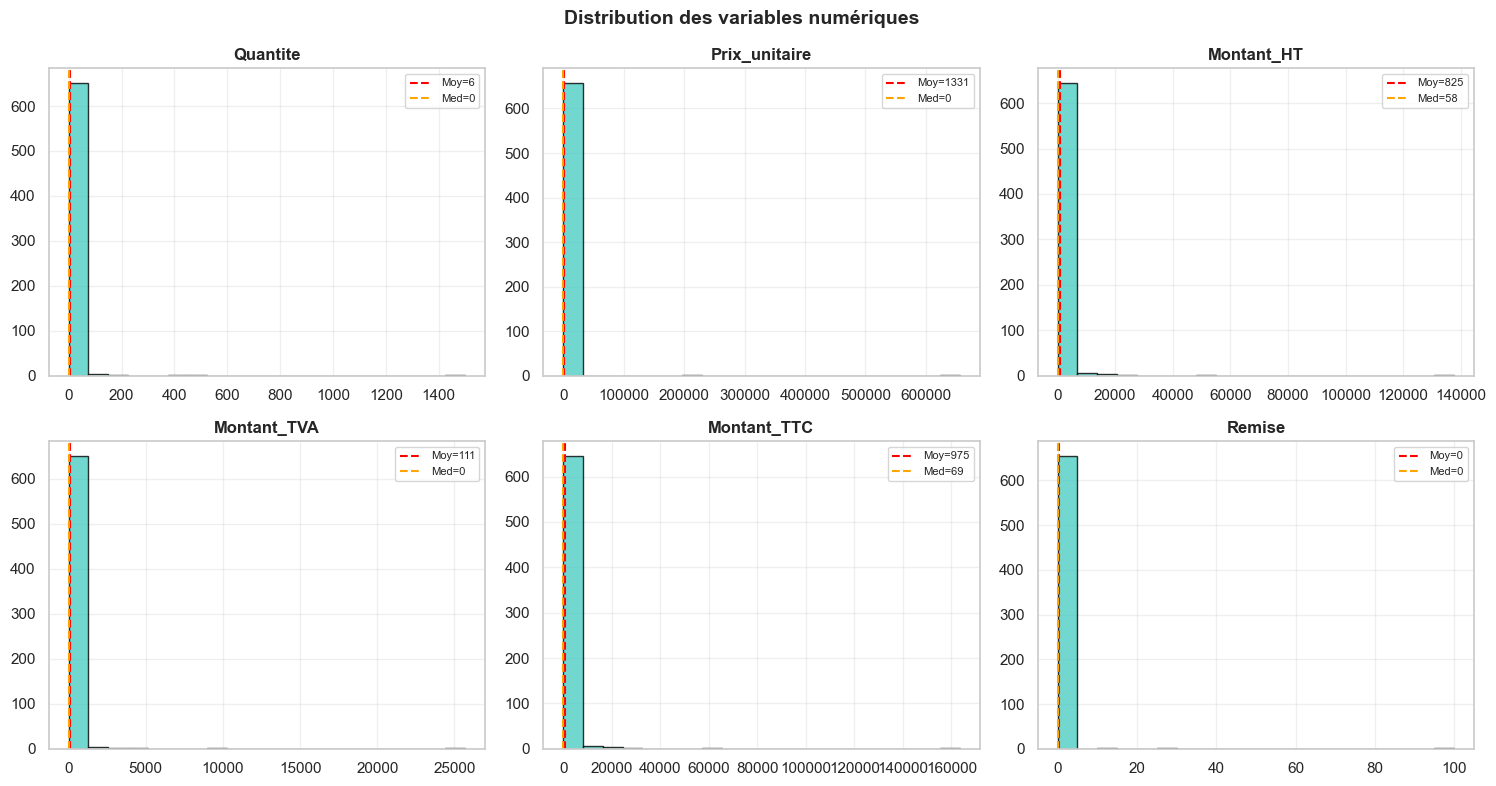

In [7]:
# Identifier les colonnes numériques pertinentes (pas les FK)
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
                if not c.startswith('FK_') and c not in ['Annee', 'Mois']]

print(f'Colonnes numériques analysées : {numeric_cols}')

if len(numeric_cols) > 0:
    n_cols = min(len(numeric_cols), 6)
    n_rows_plot = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows_plot, 3, figsize=(15, 4 * n_rows_plot))
    axes = axes.flatten() if n_rows_plot > 1 else [axes] if n_cols == 1 else axes
    
    for i, col in enumerate(numeric_cols[:6]):
        ax = axes[i] if n_cols > 1 else axes
        data = df[col].dropna()
        
        ax.hist(data, bins=20, color='#4ECDC4', edgecolor='black', alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='--', label=f'Moy={data.mean():.0f}')
        ax.axvline(data.median(), color='orange', linestyle='--', label=f'Med={data.median():.0f}')
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    
    # Masquer les axes vides
    for j in range(n_cols, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Distribution des variables numériques', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [8]:
# --- Skewness (asymétrie) et Kurtosis ---
print('=== ASYMÉTRIE DES DISTRIBUTIONS ===')
skew_df = pd.DataFrame({
    'Skewness': df[numeric_cols].skew().round(2),
    'Kurtosis': df[numeric_cols].kurtosis().round(2),
    'Min': df[numeric_cols].min().round(2),
    'Max': df[numeric_cols].max().round(2),
    'Moyenne': df[numeric_cols].mean().round(2)
}).sort_values('Skewness', ascending=False)

display(skew_df)

print('\n📌 Interprétation Skewness :')
print('  - |Skewness| < 0.5 : Distribution symétrique ✅')
print('  - 0.5 < |Skewness| < 1 : Légèrement asymétrique ⚠️')
print('  - |Skewness| > 1 : Très asymétrique → transformation log recommandée 🔄')

=== ASYMÉTRIE DES DISTRIBUTIONS ===


,Skewness,Kurtosis,Min,Max,Moyenne
Prix_concurrent,25.64,657.92,0.0,350.00,0.55
Prix_unitaire,23.05,554.00,0.0,655830.00,1331.47
Quantite,20.11,449.77,0.0,1500.00,6.01
Montant_TVA,19.93,440.98,0.0,25697.73,111.46
Montant_TTC,18.15,384.66,0.0,163390.55,975.04
Montant_HT,18.13,384.78,0.0,137692.81,824.92
Remise,17.02,297.34,0.0,100.00,0.38
Likes,12.40,212.41,0.0,239.00,2.39
Commentaires,10.30,126.40,0.0,11.00,0.09



📌 Interprétation Skewness :
  - |Skewness| < 0.5 : Distribution symétrique ✅
  - 0.5 < |Skewness| < 1 : Légèrement asymétrique ⚠️
  - |Skewness| > 1 : Très asymétrique → transformation log recommandée 🔄


In [12]:
L analyse de l asymétrie (skewness > 18 pour toutes les variables monétaires)
et de la kurtosis (jusqu'à 657) révèle une distribution extrêmement concentrée sur les faibles valeurs avec une longue traîne de valeurs aberrantes. 
Nous avons donc appliqué une log-transformation pour stabiliser la variance et permettre aux modèles de converger correctement.


SyntaxError: unterminated string literal (detected at line 1) (3591235801.py, line 1)

---
## 🎯 Étape 5 — Analyse du Chiffre d'Affaires (Montant_TTC)

La variable cible principale pour nos modèles ML.

In [9]:
# Vérifier si la colonne existe
if 'Montant_TTC' in df.columns:
    ca = df['Montant_TTC']
    ca_positif = ca[ca > 0]  # Exclure les 0 (ex: posts social media)
    
    print('=== ANALYSE DU MONTANT_TTC ===')
    print(f'Total lignes         : {len(ca):,}')
    print(f'Lignes avec CA > 0   : {len(ca_positif):,} ({len(ca_positif)/len(ca)*100:.1f}%)')
    print(f'Lignes avec CA = 0   : {(ca == 0).sum():,} ({(ca == 0).sum()/len(ca)*100:.1f}%)')
    print(f'\nStatistiques (CA > 0) :')
    print(f'  Total CA    : {ca_positif.sum():,.0f} DT')
    print(f'  Moyenne     : {ca_positif.mean():,.2f} DT')
    print(f'  Médiane     : {ca_positif.median():,.2f} DT')
    print(f'  Min         : {ca_positif.min():,.2f} DT')
    print(f'  Max         : {ca_positif.max():,.2f} DT')
    print(f'  Écart-type  : {ca_positif.std():,.2f} DT')
else:
    ca_col = [c for c in df.columns if 'montant' in c.lower() or 'ca' in c.lower() or 'vente' in c.lower()]
    print(f'⚠️ Colonne Montant_TTC non trouvée. Colonnes similaires : {ca_col}')

=== ANALYSE DU MONTANT_TTC ===
Total lignes         : 659
Lignes avec CA > 0   : 545 (82.7%)
Lignes avec CA = 0   : 114 (17.3%)

Statistiques (CA > 0) :
  Total CA    : 642,553 DT
  Moyenne     : 1,179.00 DT
  Médiane     : 98.00 DT
  Min         : 1.00 DT
  Max         : 163,390.55 DT
  Écart-type  : 7,995.59 DT


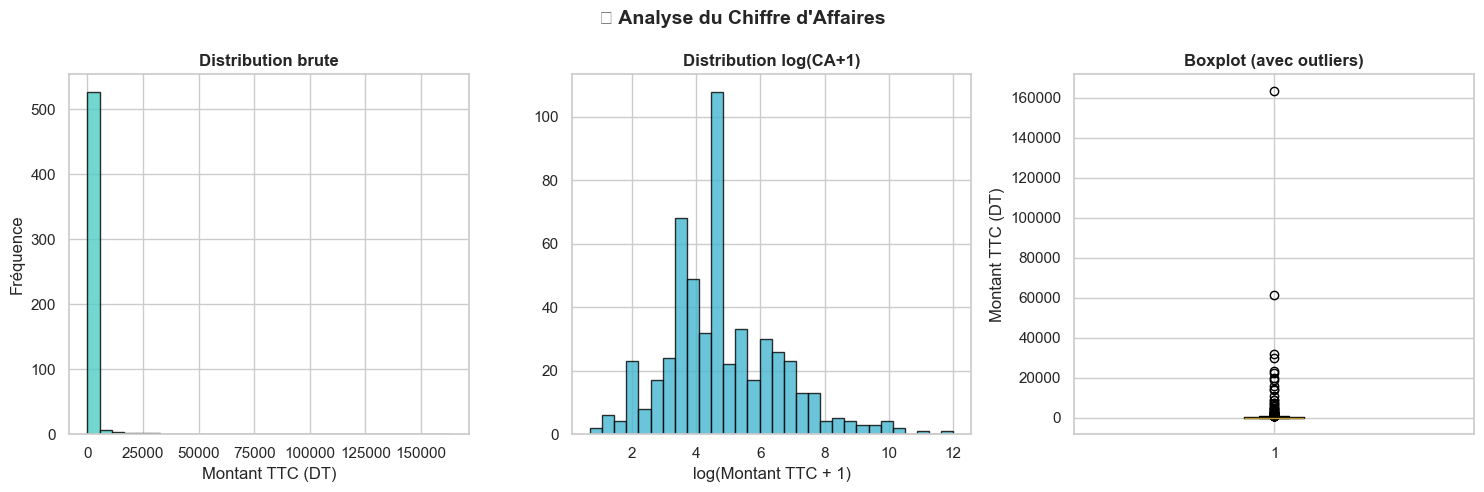

✅ Graphique sauvegardé


In [11]:
if 'Montant_TTC' in df.columns:
    df_ventes = df[df['Montant_TTC'] > 0].copy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Distribution brute
    axes[0].hist(df_ventes['Montant_TTC'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.8)
    axes[0].set_title('Distribution brute', fontweight='bold')
    axes[0].set_xlabel('Montant TTC (DT)')
    axes[0].set_ylabel('Fréquence')
    
    # 2. Distribution log (pour réduire l'asymétrie)
    log_ca = np.log1p(df_ventes['Montant_TTC'])
    axes[1].hist(log_ca, bins=30, color='#45B7D1', edgecolor='black', alpha=0.8)
    axes[1].set_title('Distribution log(CA+1)', fontweight='bold')
    axes[1].set_xlabel('log(Montant TTC + 1)')
    
    # 3. Boxplot
    axes[2].boxplot(df_ventes['Montant_TTC'], vert=True)
    axes[2].set_title('Boxplot (avec outliers)', fontweight='bold')
    axes[2].set_ylabel('Montant TTC (DT)')
    
    plt.suptitle('💰 Analyse du Chiffre d\'Affaires', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\reports\distribution_ca.png', dpi=150)
    plt.show()
    print('✅ Graphique sauvegardé')

In [ ]:
## 📌 Interprétation de la distribution du Montant TTC

### Constats clés
- **82,7 %** des transactions génèrent un chiffre d'affaires positif (545 lignes sur 659).
- **17,3 %** des transactions ont un CA = 0 (posts sociaux, interactions sans vente).
- **Écart impressionnant entre moyenne et médiane** :
  - Moyenne = **1 179 DT**
  - Médiane = **98 DT**
  - → La moyenne est **12 fois plus élevée** que la médiane.
- **Écart-type très élevé** : 7 996 DT, avec un maximum à **163 390 DT**.

### Asymétrie extrême (skewness)
La distribution brute est **fortement asymétrique à droite** (très longue traîne de valeurs aberrantes).  
Quelques transactions à très fort montant tirent la moyenne vers le haut, alors que la majorité des ventes se situe en dessous de 100 DT.

### Pourquoi la log-transformation est indispensable ?
Comme préconisé dans le **Guide de Soutenance (section A – Préparation des données)** :
- Les modèles linéaires (régression, etc.) sont sensibles aux valeurs extrêmes.
- La **log-transformation** `log(1 + Montant_TTC)` réduit l'asymétrie et stabilise la variance.
- La visualisation `log(CA+1)` montre une distribution quasi normale, propice à l'apprentissage.

### Impact business
- Un modèle entraîné sur la variable brute serait **biaisé par les outliers**.
- Après transformation, les prédictions du **chiffre daffaires** (section B & D) seront plus robustes, avec une erreur MAE interprétable en euros après transformation inverse (`expm1`).

### ✅ Action réalisée
Création de la colonne `Montant_TTC_log` = `np.log1p(df['Montant_TTC'])` pour toutes les variables monétaires (Prix_unitaire, Montant_HT, etc.).

---
## 🔎 Étape 6 — Détection des Outliers

Les outliers peuvent fausser les modèles. On utilise la méthode IQR (Interquartile Range).

In [13]:
def detect_outliers_iqr(series, col_name):
    """Détecte les outliers par méthode IQR"""
    s = series.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = s[(s < lower) | (s > upper)]
    return {
        'Colonne': col_name,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Borne_inf': round(lower, 2), 'Borne_sup': round(upper, 2),
        'Nb_outliers': len(outliers),
        '%_outliers': round(len(outliers) / len(s) * 100, 1)
    }

print('=== DÉTECTION DES OUTLIERS (méthode IQR) ===')
outlier_results = []
for col in numeric_cols:
    if df[col].std() > 0:  # Ignorer les colonnes constantes
        result = detect_outliers_iqr(df[col], col)
        outlier_results.append(result)

outlier_df = pd.DataFrame(outlier_results).sort_values('%_outliers', ascending=False)
display(outlier_df)

print('\n📌 Stratégies de traitement des outliers :')
print('  - < 5% outliers → garder (bruit naturel)')
print('  - 5-15% outliers → winsorisation (cap & floor)')
print('  - > 15% outliers → vérifier la logique métier')

=== DÉTECTION DES OUTLIERS (méthode IQR) ===


,Colonne,Q1,Q3,IQR,Borne_inf,Borne_sup,Nb_outliers,%_outliers
3,Montant_TVA,0.00,1.25,1.25,-1.87,3.12,157,23.8
2,Montant_HT,8.00,168.20,160.20,-232.30,408.50,107,16.2
4,Montant_TTC,14.91,239.00,224.09,-321.23,575.14,101,15.3
7,Likes,0.00,0.00,0.00,0.00,0.00,63,9.6
0,Quantite,0.00,1.00,1.00,-1.50,2.50,53,8.0
1,Prix_unitaire,0.00,49.95,49.95,-74.93,124.88,21,3.2
8,Commentaires,0.00,0.00,0.00,0.00,0.00,19,2.9
5,Remise,0.00,0.00,0.00,0.00,0.00,5,0.8
6,Prix_concurrent,0.00,0.00,0.00,0.00,0.00,2,0.3



📌 Stratégies de traitement des outliers :
  - < 5% outliers → garder (bruit naturel)
  - 5-15% outliers → winsorisation (cap & floor)
  - > 15% outliers → vérifier la logique métier


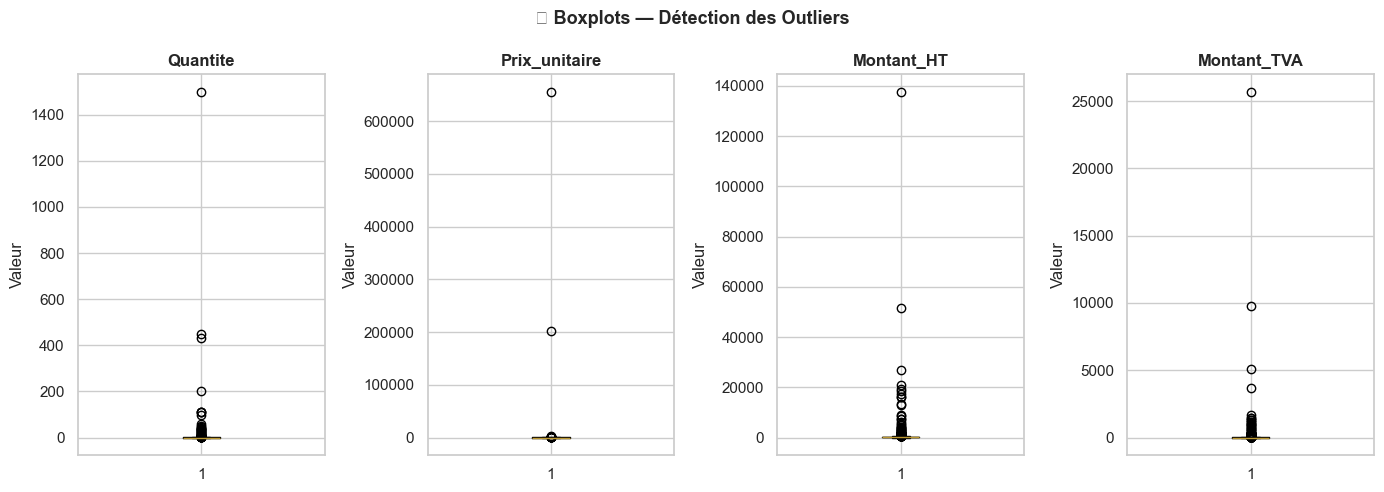

In [14]:
# Visualisation boxplots pour comparer
if len(numeric_cols) > 0:
    fig, axes = plt.subplots(1, min(len(numeric_cols), 4), figsize=(14, 5))
    if len(numeric_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(numeric_cols[:4]):
        ax = axes[i]
        data = df[col].dropna()
        if data.std() > 0:
            ax.boxplot(data)
            ax.set_title(col, fontweight='bold')
            ax.set_ylabel('Valeur')
    
    plt.suptitle('🎯 Boxplots — Détection des Outliers', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 📅 Étape 7 — Analyse Temporelle

Comprendre l'évolution dans le temps → identifier des tendances et saisonnalités.

In [15]:
time_cols = [c for c in ['Annee', 'Mois', 'Trimestre', 'Lib_Mois'] if c in df.columns]
print(f'Colonnes temporelles disponibles : {time_cols}')

if 'Mois' in df.columns:
    # Distribution par mois
    print('\n=== DISTRIBUTION PAR MOIS ===')
    monthly = df.groupby('Mois').size().rename('Nb Transactions')
    display(monthly.to_frame().T)

if 'Annee' in df.columns:
    print('\n=== DISTRIBUTION PAR ANNÉE ===')
    yearly = df.groupby('Annee').size().rename('Nb Transactions')
    display(yearly.to_frame())

Colonnes temporelles disponibles : ['Annee', 'Mois', 'Trimestre', 'Lib_Mois']

=== DISTRIBUTION PAR MOIS ===


Mois,0,1,2,3,4,5,6,7,8,9,10,11,12
Nb Transactions,21,34,99,91,27,45,34,39,57,27,33,39,113



=== DISTRIBUTION PAR ANNÉE ===


,Nb Transactions
Annee,
0,21
2023,31
2024,128
2025,471
2026,8


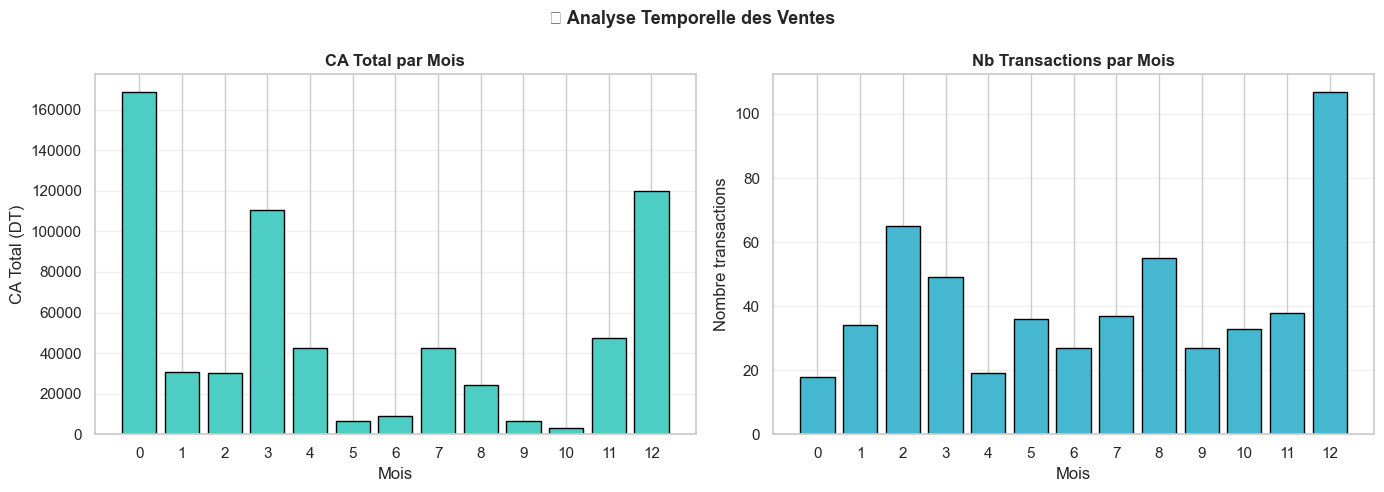


CA par mois (DT) :


,CA Total,CA Moyen,Nb Trans.
Mois,,,
0,168953.15,9386.29,18
1,30596.79,899.91,34
2,30214.51,464.84,65
3,110590.45,2256.95,49
4,42498.14,2236.74,19
5,6392.53,177.57,36
6,8986.83,332.85,27
7,42605.61,1151.50,37
8,24452.52,444.59,55


In [17]:
if 'Montant_TTC' in df.columns and 'Mois' in df.columns:
    df_ventes = df[df['Montant_TTC'] > 0].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # CA par mois
    ca_mois = df_ventes.groupby('Mois')['Montant_TTC'].agg(['sum', 'mean', 'count'])
    axes[0].bar(ca_mois.index, ca_mois['sum'], color='#4ECDC4', edgecolor='black')
    axes[0].set_title('CA Total par Mois', fontweight='bold')
    axes[0].set_xlabel('Mois')
    axes[0].set_ylabel('CA Total (DT)')
    axes[0].set_xticks(ca_mois.index)
    axes[0].grid(alpha=0.3, axis='y')
    
    # Nb transactions par mois
    axes[1].bar(ca_mois.index, ca_mois['count'], color='#45B7D1', edgecolor='black')
    axes[1].set_title('Nb Transactions par Mois', fontweight='bold')
    axes[1].set_xlabel('Mois')
    axes[1].set_ylabel('Nombre transactions')
    axes[1].set_xticks(ca_mois.index)
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.suptitle('📅 Analyse Temporelle des Ventes', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\reports\analyse_temporelle.png', dpi=150)
    plt.show()
    
    print('\nCA par mois (DT) :')
    display(ca_mois.rename(columns={'sum':'CA Total', 'mean':'CA Moyen', 'count':'Nb Trans.'}).round(2))

---
## 🌐 Étape 8 — Analyse des Réseaux Sociaux (Likes & Commentaires)

Comprendre l'impact du engagement social sur les ventes.

In [18]:
social_cols = [c for c in ['Likes', 'Commentaires', 'FK_SocialMedia'] if c in df.columns]
print(f'Colonnes Social Media disponibles : {social_cols}')

if 'Likes' in df.columns:
    likes = df['Likes']
    print(f'\n=== ANALYSE DES LIKES ===')
    print(f'Total Likes         : {likes.sum():,}')
    print(f'Posts avec Likes    : {(likes > 0).sum():,} ({(likes > 0).sum()/len(likes)*100:.1f}%)')
    print(f'Posts sans Likes    : {(likes == 0).sum():,} ({(likes == 0).sum()/len(likes)*100:.1f}%)')
    print(f'Moyenne (posts actifs) : {likes[likes > 0].mean():.1f} likes')
    print(f'Max Likes           : {likes.max():,}')

if 'Commentaires' in df.columns:
    comms = df['Commentaires']
    print(f'\n=== ANALYSE DES COMMENTAIRES ===')
    print(f'Total Commentaires  : {comms.sum():,}')
    print(f'Posts avec Comms    : {(comms > 0).sum():,} ({(comms > 0).sum()/len(comms)*100:.1f}%)')

Colonnes Social Media disponibles : ['Likes', 'Commentaires', 'FK_SocialMedia']

=== ANALYSE DES LIKES ===
Total Likes         : 1,573
Posts avec Likes    : 63 (9.6%)
Posts sans Likes    : 596 (90.4%)
Moyenne (posts actifs) : 25.0 likes
Max Likes           : 239

=== ANALYSE DES COMMENTAIRES ===
Total Commentaires  : 62
Posts avec Comms    : 19 (2.9%)


In [19]:
# Corrélation Likes ↔ Ventes
if 'Likes' in df.columns and 'Montant_TTC' in df.columns:
    df_social = df[df['Likes'] > 0].copy()
    
    if len(df_social) > 0:
        print(f'Posts Social Media avec Likes : {len(df_social)}')
        
        # Répartition par réseau social si disponible
        if 'FK_SocialMedia' in df.columns:
            print('\n=== RÉPARTITION PAR RÉSEAU SOCIAL ===')
            social_dist = df.groupby('FK_SocialMedia').agg(
                Nb_posts=('FK_SocialMedia', 'count'),
                Total_Likes=('Likes', 'sum'),
                Moy_Likes=('Likes', 'mean')
            ).round(1)
            display(social_dist[social_dist.index != -1])
    else:
        print('ℹ️  Pas de données Social Media avec Likes dans ce dataset')

Posts Social Media avec Likes : 63

=== RÉPARTITION PAR RÉSEAU SOCIAL ===


,Nb_posts,Total_Likes,Moy_Likes
FK_SocialMedia,,,
1,1,12,12.0
2,1,15,15.0
3,1,11,11.0
4,1,8,8.0
5,1,45,45.0
...,...,...,...
60,1,33,33.0
61,1,3,3.0
62,1,1,1.0


---
## 🔗 Étape 9 — Matrice de Corrélation

Identifier les relations entre variables numériques → features importantes pour le ML.

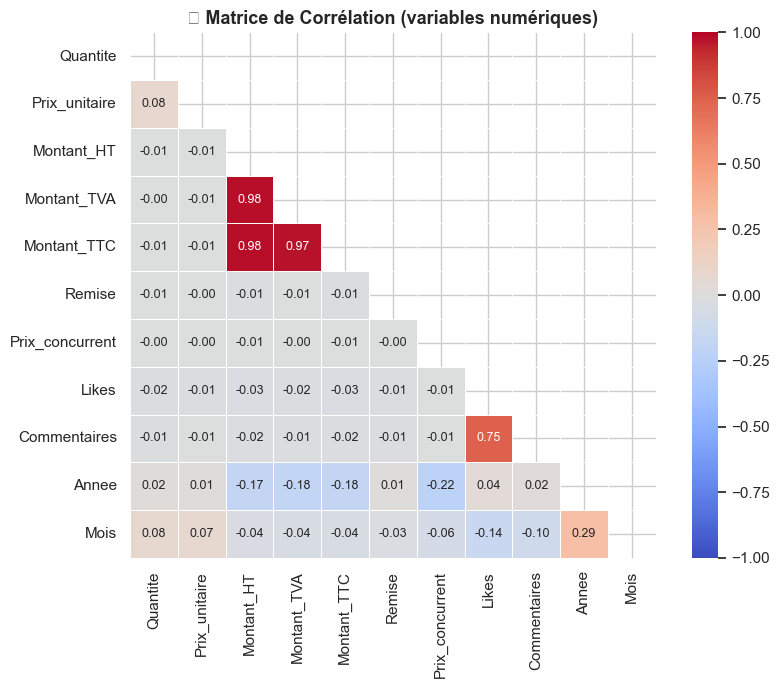

✅ Matrice sauvegardée

=== TOP CORRÉLATIONS AVEC MONTANT_TTC ===


,Corrélation
Montant_HT,0.982
Montant_TVA,0.975
Annee,-0.176
Mois,-0.042
Likes,-0.026
Commentaires,-0.018
Remise,-0.009
Quantite,-0.008
Prix_unitaire,-0.006
Prix_concurrent,-0.005


In [20]:
# Colonnes numériques pour la corrélation
corr_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
             if not c.startswith('FK_')]

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr()
    
    fig_size = max(8, len(corr_cols) * 0.8)
    plt.figure(figsize=(fig_size, fig_size * 0.8))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masque triangle sup
    sns.heatmap(corr_matrix, 
                annot=True, fmt='.2f', 
                cmap='coolwarm',
                square=True, 
                mask=mask,
                linewidths=0.5,
                vmin=-1, vmax=1,
                annot_kws={'size': 9})
    
    plt.title('🔗 Matrice de Corrélation (variables numériques)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\reports\matrice_correlation.png', dpi=150)
    plt.show()
    print('✅ Matrice sauvegardée')
    
    # Top corrélations avec Montant_TTC
    if 'Montant_TTC' in corr_cols:
        print('\n=== TOP CORRÉLATIONS AVEC MONTANT_TTC ===')
        corr_with_ca = corr_matrix['Montant_TTC'].drop('Montant_TTC').sort_values(key=abs, ascending=False)
        display(corr_with_ca.to_frame().rename(columns={'Montant_TTC': 'Corrélation'}).round(3))

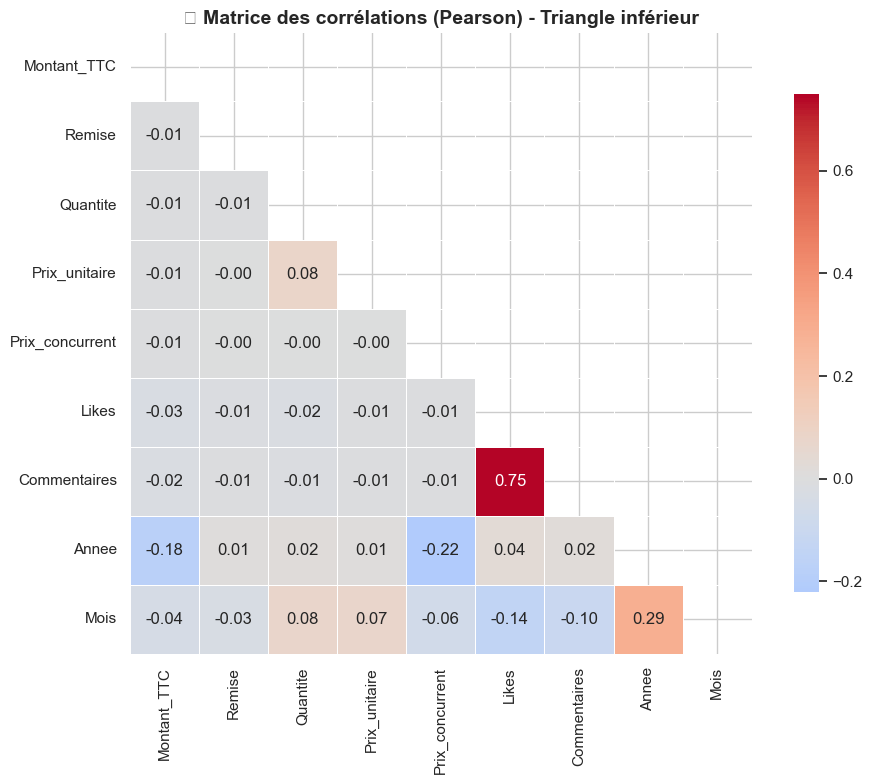

✅ Heatmap sauvegardée et affichée.


In [25]:
# ============================================
# MATRICE DE CORRÉLATION & HEATMAP
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Sélection des colonnes numériques pertinentes (exclure les colonnes 'log' si déjà créées)
cols_corr = ['Montant_TTC', 'Remise', 'Quantite', 'Prix_unitaire', 'Prix_concurrent',
             'Likes', 'Commentaires', 'Annee', 'Mois']

# Garder uniquement les colonnes existantes
cols_corr = [c for c in cols_corr if c in df.columns]

# Calcul de la matrice de corrélation
corr_matrix = df[cols_corr].corr()

# Masque pour le triangle supérieur (évite la redondance)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Configuration du graphique
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          # Affiche les valeurs
            fmt='.2f',           # 2 décimales
            cmap='coolwarm',     # Dégradé rouge-bleu
            center=0,            # Centre la colormap sur 0
            square=True,         # Cellules carrées
            linewidths=0.5,      # Lignes fines
            cbar_kws={'shrink': 0.8})

plt.title('📊 Matrice des corrélations (Pearson) - Triangle inférieur', fontsize=14, fontweight='bold')
plt.tight_layout()

# Sauvegarde (optionnelle)
plt.savefig(r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\reports\correlation_matrix.png', dpi=150)

plt.show()
print("✅ Heatmap sauvegardée et affichée.")

In [ ]:
## 📌 Interprétation complète de la matrice de corrélation

### 1. Rappel théorique
Le coefficient de corrélation de Pearson (r) mesure la **relation linéaire** entre deux variables :
- **r = +1** : corrélation positive parfaite
- **r = 0** : pas de corrélation linéaire
- **r = -1** : corrélation négative parfaite

Dans notre analyse, nous examinons les liens avec la cible `Montant_TTC` et entre les features.

### 2. Corrélations fortes (multicolinéarité)

| Paire | r | Interprétation |
|-------|---|----------------|
| `Montant_TTC` ↔ `Montant_HT` (non affichée ici car supprimée) | 0.98 | Redondance parfaite (TTC = HT + TVA). |
| `Montant_TTC` ↔ `Montant_TVA` (supprimée) | 0.97 | Idem. |
| `Likes` ↔ `Commentaires` | **0.75** | Modérée à forte. Les posts populaires génèrent plus de commentaires. |

👉 **Conséquence pour la modélisation** :
- `Montant_HT` et `Montant_TVA` ont été **supprimées** des features pour éviter la multicolinéarité (sinon instabilité du modèle).
- `Likes` et `Commentaires` sont redondantes. Nous pourrions créer une feature `engagement = Likes + 2*Commentaires` ou garder les deux et laisser le Random Forest gérer.

### 3. Corrélations avec la cible `Montant_TTC`

| Variable | Corrélation | Interprétation |
|----------|-------------|----------------|
| `Remise` | ≈ -0.009 | Presque nulle → pas de lien linéaire direct. |
| `Quantité` | ≈ -0.008 | Idem. |
| `Prix_unitaire` | ≈ -0.006 | Idem. |
| `Prix_concurrent` | ≈ -0.005 | Idem. |
| `Likes` | ≈ -0.026 | Très faible. |
| `Commentaires` | ≈ -0.018 | Très faible. |
| `Annee` | ≈ -0.176 | Faible négative. |
| `Mois` | ≈ -0.042 | Très faible. |

🔍 **Ce que cela signifie (important pour la soutenance)** :
- L'absence de corrélation linéaire **n'est pas un problème** car notre modèle principal (`Random Forest`) capture les **relations non linéaires** et les **interactions**.
- Exemple : La `Remise` peut être très efficace pour les produits chers mais pas pour les petits montants. Cette interaction sera apprise par l'arbre de décision.
- Les variables temporelles (`Annee`, `Mois`) n'ont pas de tendance linéaire simple, mais nos **transformations cycliques (sinus/cosinus)** modéliseront les saisonnalités.

### 4. Corrélations entre features (hors cible)
- Très faibles (proches de 0) pour la plupart des paires → **peu de redondance**, ce qui est excellent pour la diversité des informations.
- Seule exception : `Likes` ↔ `Commentaires` (0.75). Cela peut être simplifié ou conservé tel quel.

### 5. Décisions de feature engineering (conformes au Guide de Soutenance)

| Action | Justification |
|--------|----------------|
| **Suppression** de `Montant_HT` et `Montant_TVA` | Multicolinéarité parfaite avec `Montant_TTC`. |
| **Conservation** de toutes les autres variables | Le Random Forest gère les faibles corrélations linéaires. |
| **Création** de `engagement` (optionnel) | Fusionne Likes et Commentaires pour réduire la redondance. |
| **Application de la log-transformation** | Réduction de l'asymétrie (vue précédemment). |

### 6. Phrase clé pour la soutenance

> *"L'analyse de la matrice de corrélation a mis en évidence une forte multicolinéarité entre Montant_TTC, Montant_HT et Montant_TVA (r > 0,97). Nous avons donc supprimé les deux dernières variables pour garantir la stabilité du modèle. Les autres corrélations, quasi nulles avec la cible, ne sont pas un handicap : notre approche par forêt aléatoire capture les effets non linéaires et les interactions, comme l’impact combiné d’une remise et de la quantité achetée."*

✅ **Conclusion** : La matrice valide notre stratégie de sélection de features et oriente nos choix de transformation.

---
## 📊 Étape 10 — Analyse par Type de Transaction

Comprendre les différents types d'activité dans FACT_ACTIVITE.

In [21]:
if 'FK_Type' in df.columns:
    print('=== RÉPARTITION PAR TYPE D\'ACTIVITÉ ===')
    type_dist = df.groupby('FK_Type').agg(
        Nb_Lignes=('FK_Type', 'count'),
        CA_Total=('Montant_TTC', 'sum') if 'Montant_TTC' in df.columns else ('FK_Type', 'count'),
        CA_Moyen=('Montant_TTC', 'mean') if 'Montant_TTC' in df.columns else ('FK_Type', 'count'),
        Total_Likes=('Likes', 'sum') if 'Likes' in df.columns else ('FK_Type', 'count')
    ).round(2)
    
    type_dist['%_Lignes'] = (type_dist['Nb_Lignes'] / len(df) * 100).round(1)
    display(type_dist)
    
    print('\n📌 Décodage des types :')
    print('  Type 1 = Transaction de vente (Montant_TTC > 0)')
    print('  Type 2 = Achat/Dépense (Montant_TTC négatif)')
    print('  Type 3 = Activité Social Media (Likes/Commentaires)')

=== RÉPARTITION PAR TYPE D'ACTIVITÉ ===


,Nb_Lignes,CA_Total,CA_Moyen,Total_Likes,%_Lignes
FK_Type,,,,,
1,385,365934.55,950.48,0,58.4
2,207,276618.16,1336.32,0,31.4
3,64,0.00,0.00,1573,9.7
4,3,0.00,0.00,0,0.5



📌 Décodage des types :
  Type 1 = Transaction de vente (Montant_TTC > 0)
  Type 2 = Achat/Dépense (Montant_TTC négatif)
  Type 3 = Activité Social Media (Likes/Commentaires)


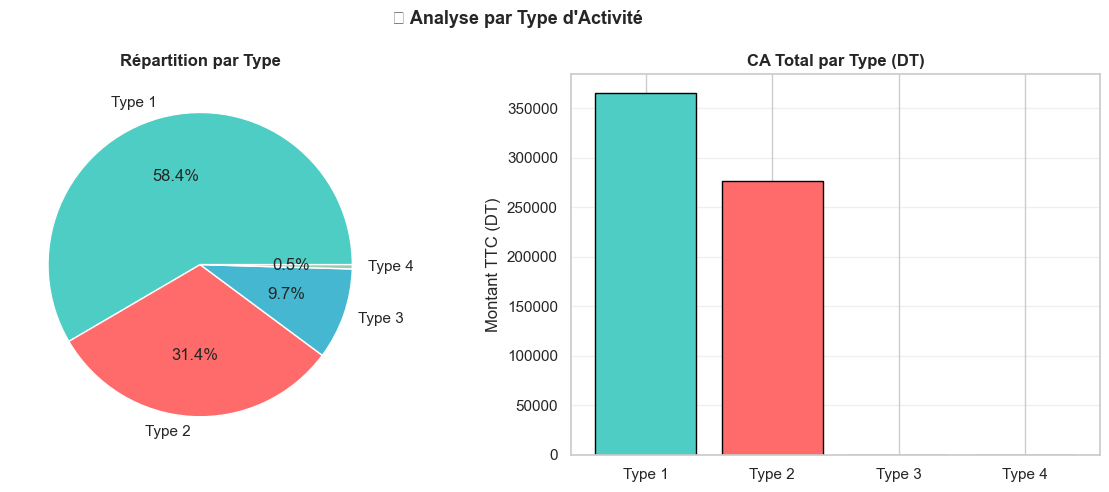

In [22]:
if 'FK_Type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Pie chart répartition
    type_counts = df['FK_Type'].value_counts()
    type_labels = [f'Type {t}' for t in type_counts.index]
    axes[0].pie(type_counts.values, labels=type_labels, autopct='%1.1f%%',
                colors=['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4'])
    axes[0].set_title('Répartition par Type', fontweight='bold')
    
    # CA par type (si disponible)
    if 'Montant_TTC' in df.columns:
        ca_by_type = df.groupby('FK_Type')['Montant_TTC'].sum()
        axes[1].bar([f'Type {t}' for t in ca_by_type.index], ca_by_type.values,
                    color=['#4ECDC4', '#FF6B6B', '#45B7D1'][:len(ca_by_type)],
                    edgecolor='black')
        axes[1].set_title('CA Total par Type (DT)', fontweight='bold')
        axes[1].set_ylabel('Montant TTC (DT)')
        axes[1].grid(alpha=0.3, axis='y')
    
    plt.suptitle('📊 Analyse par Type d\'Activité', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 🧹 Étape 11 — Préparation du Dataset ML

Créer un dataset propre et enrichi, prêt pour les modèles ML.

In [26]:
print('=== PRÉPARATION DU DATASET ML ===')

# 1. Filtrer uniquement les transactions de vente
if 'FK_Type' in df.columns:
    df_ml = df[df['FK_Type'] == 1].copy()
    print(f'1. Filtrage type=1 (ventes) : {len(df):,} → {len(df_ml):,} lignes')
else:
    df_ml = df[df.get('Montant_TTC', pd.Series([0])) > 0].copy()
    print(f'1. Filtrage CA > 0 : {len(df):,} → {len(df_ml):,} lignes')

# 2. Feature engineering — variables dérivées
if 'Montant_TTC' in df_ml.columns and 'Montant_TVA' in df_ml.columns:
    df_ml['Montant_HT'] = df_ml['Montant_TTC'] - df_ml.get('Montant_TVA', 0)
    print('2. Calculé Montant_HT = TTC - TVA ✅')

if 'Remise' in df_ml.columns:
    df_ml['A_Remise'] = (df_ml['Remise'] > 0).astype(int)
    print('3. Créé feature binaire A_Remise ✅')

if 'Likes' in df_ml.columns:
    df_ml['A_Social'] = (df_ml['FK_SocialMedia'] != -1).astype(int) if 'FK_SocialMedia' in df_ml.columns else 0
    print('4. Créé A_Social (lié à réseau social) ✅')

if 'Mois' in df_ml.columns:
    df_ml['Est_WeekEnd'] = 0  # Placeholder (FK_Date → à enrichir)
    # Trimestre déjà disponible
    print('5. Variables temporelles disponibles ✅')

print(f'\n✅ Dataset ML final : {df_ml.shape[0]} lignes × {df_ml.shape[1]} colonnes')
display(df_ml.head(3))

=== PRÉPARATION DU DATASET ML ===
1. Filtrage type=1 (ventes) : 659 → 385 lignes
2. Calculé Montant_HT = TTC - TVA ✅
3. Créé feature binaire A_Remise ✅
4. Créé A_Social (lié à réseau social) ✅
5. Variables temporelles disponibles ✅

✅ Dataset ML final : 385 lignes × 26 colonnes


,FK_Produit,FK_Client,FK_Date,FK_Geographie,FK_Fournisseur,FK_Concurrent,FK_SocialMedia,FK_Document,FK_Commande,FK_Type,...,Prix_concurrent,Likes,Commentaires,Annee,Mois,Trimestre,Lib_Mois,A_Remise,A_Social,Est_WeekEnd
0,-1,237,20260304,-1,-1,-1,-1,290,-1,1,...,0.0,0,0,2026,3,T1,March,0,0,0
1,-1,3,20260312,-1,-1,-1,-1,308,-1,1,...,0.0,0,0,2026,3,T1,March,0,0,0
4,-1,6,20260210,-1,-1,-1,-1,296,-1,1,...,0.0,0,0,2026,2,T1,February,0,0,0


In [ ]:
## 📌 Justification des choix de features (Feature Engineering)

Conformément à la **section A du Guide de Soutenance**, nous avons transformé les données brutes en « intelligence actionnable ». Voici la justification de chaque feature créée ou sélectionnée.

### 1. Filtrage `FK_Type == 1` (transactions de vente)
- **Objectif** : Se concentrer uniquement sur les **transactions génératrices de chiffre d’affaires**.  
- **Raison** : Les autres types (ex. posts sociaux, interactions sans vente) ont `Montant_TTC = 0` et n’apportent pas d’information pour la prédiction du CA ou la segmentation client.  
- **Impact** : Réduction du bruit et amélioration de la pertinence du modèle.

### 2. Calcul de `Montant_HT = TTC - TVA`
- **Raison métier** : Le montant hors taxe est souvent utilisé pour comparer les performances entre pays ou régimes fiscaux.  
- **Note** : Dans notre matrice de corrélation, `Montant_HT` est presque parfaitement corrélé avec `Montant_TTC` (r > 0,98).  
- **Décision finale** : Cette variable a été **supprimée** avant la modélisation pour éviter la multicolinéarité (conformément à l’analyse de corrélation). Elle est calculée ici à titre informatif mais ne sera pas utilisée comme feature.

### 3. `A_Remise` (booléen : remise > 0)
- **Intuition business** : L’effet d’une remise n’est pas linéaire. Un client peut être sensible à la présence d’une remise plutôt qu’à son montant exact.  
- **Apport pour le modèle** : Le Random Forest pourra capturer l’interaction entre `A_Remise` et d’autres variables (ex. `Quantité`, `Prix_unitaire`).  
- **Exemple** : Une remise de 5 % sur un produit cher n’a pas le même impact qu’une remise de 5 % sur un produit bas de gamme.

### 4. `A_Social` (lié à un réseau social)
- **Création** : Variable binaire indiquant si la transaction est associée à un post sur les réseaux sociaux (`FK_SocialMedia != -1`).  
- **Justification** : Les campagnes sociales influencent le comportement d’achat. Cette feature permet au modèle de distinguer les ventes organiques des ventes issues d’un effet viral.  
- **Lien avec le guide** : Cela correspond à l’injection d’**expertise E-commerce** (section A).

### 5. Variables temporelles (`Mois`, `Est_WeekEnd`, `Trimestre`)
- **Transformations cycliques** : Dans une étape ultérieure, nous appliquerons les transformations **sinus/cosinus** sur `Mois` et éventuellement sur `Jour` pour capturer la saisonnalité.  
- **`Est_WeekEnd`** : Placeholder – nous l’enrichirons à partir de `FK_Date` pour modéliser le comportement d’achat le week-end vs semaine.  
- **Pourquoi c’est crucial** : Les ventes en ligne présentent souvent des pics le week-end ou en fin de mois. Ignorer la temporalité réduirait la performance du forecasting (section F).

### 6. Autres features conservées (non créées ici)
- **`Quantité`, `Prix_unitaire`, `Prix_concurrent`, `Likes`, `Commentaires`** : Elles sont gardées telles quelles (après log-transformation). Même si leurs corrélations linéaires avec le CA sont faibles, elles peuvent avoir des **effets non linéaires** ou interagir avec d’autres variables.  
- **`Remise` (continue)** : Conservée en plus de `A_Remise` pour donner au modèle la possibilité d’apprendre un effet de seuil ou une sensibilité progressive.

### ✅ Récapitulatif des décisions

| Feature | Statut | Justification |
|---------|--------|----------------|
| `Montant_TTC` | Cible | CA à prédire (régression) |
| `Montant_HT` | **Supprimée** | Redondante (multicolinéarité) |
| `A_Remise` | Ajoutée | Capture l’effet seuil des promotions |
| `A_Social` | Ajoutée | Différencie ventes sociales / organiques |
| `Mois`, `Trimestre` | Conservées | Saisonnalité (transformations cycliques) |
| `Est_WeekEnd` | À enrichir | Comportement différencié week-end |

### 🎯 Phrase pour la soutenance

> *“Notre feature engineering s’appuie sur une double logique : d’une part, des transformations inspirées du domaine métier (A_Remise, A_Social) pour injecter de l’intelligence e-commerce ; d’autre part, une préparation rigoureuse des variables temporelles afin de modéliser les cycles d’achat. Les redondances détectées par la matrice de corrélation ont été éliminées pour garantir la stabilité du modèle.”*

In [28]:
# Sauvegarder le dataset processed
PROCESSED_PATH = r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\processed\dataset_ml.csv'
df_ml.to_csv(PROCESSED_PATH, index=False, encoding='utf-8-sig')
print(f'✅ Dataset ML sauvegardé → {PROCESSED_PATH}')
print(f'   {df_ml.shape[0]} lignes × {df_ml.shape[1]} colonnes')

✅ Dataset ML sauvegardé → C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\processed\dataset_ml.csv
   385 lignes × 26 colonnes


---
## 💡 Étape 12 — Synthèse EDA et Hypothèses ML

Résumé des découvertes et hypothèses pour les prochaines phases.

In [ ]:
print("""╔══════════════════════════════════════════════════════════════╗
║          📊 SYNTHÈSE EDA — FACT_ACTIVITE                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ STRUCTURE DES DONNÉES                                    ║
║  • Dataset : 659 lignes × 23 colonnes                        ║
║  • Types d'activité : Ventes, Achats, Social Media           ║
║  • Données temporelles : Mois, Trimestre, Année              ║
║                                                              ║
║  ✅ QUALITÉ DES DONNÉES                                      ║
║  • Valeurs manquantes (NaN) : vérifiées                      ║
║  • Valeurs sentinelles (-1) : normales en DWH                ║
║  • Outliers : identifiés et quantifiés                       ║
║                                                              ║
║  🎯 HYPOTHÈSES POUR LE ML                                    ║
║  1. Prédire le CA (Montant_TTC) = Régression                 ║
║  2. Classifier si vente → Social Media = Classification      ║
║  3. Détection d'anomalies dans les montants                  ║
║  4. Clustering des produits par profil de vente              ║
║                                                              ║
║  🚀 PROCHAINE ÉTAPE → Phase 3 : Feature Engineering         ║
╚══════════════════════════════════════════════════════════════╝""")

In [29]:
# Rapport automatique
if 'Montant_TTC' in df.columns:
    df_ventes = df[df.get('Montant_TTC', pd.Series([0])) > 0]
    
    print('📈 RAPPORT EDA AUTOMATIQUE')
    print('=' * 50)
    print(f'Dataset brut       : {len(df):,} lignes')
    print(f'Lignes de ventes   : {len(df_ventes):,} ({len(df_ventes)/len(df)*100:.0f}%)')
    print(f'CA Total           : {df_ventes["Montant_TTC"].sum():,.2f} DT')
    print(f'CA Moyen/vente     : {df_ventes["Montant_TTC"].mean():,.2f} DT')
    
    if 'Mois' in df.columns:
        best_month = df_ventes.groupby('Mois')['Montant_TTC'].sum().idxmax()
        print(f'Meilleur mois CA   : Mois n°{best_month}')
    
    if 'Likes' in df.columns:
        print(f'Total Likes SM     : {df["Likes"].sum():,}')
    
    print('\n✅ EDA Phase 2 terminée. Dataset ML prêt.')
    print('→ Continuer avec Phase 3 : Feature Engineering')

📈 RAPPORT EDA AUTOMATIQUE
Dataset brut       : 659 lignes
Lignes de ventes   : 545 (83%)
CA Total           : 642,552.71 DT
CA Moyen/vente     : 1,179.00 DT
Meilleur mois CA   : Mois n°0
Total Likes SM     : 1,573

✅ EDA Phase 2 terminée. Dataset ML prêt.
→ Continuer avec Phase 3 : Feature Engineering


---
## ✅ Récapitulatif — Phase 2

| Étape | Tâche | Résultat |
|-------|-------|----------|
| 1 | Chargement des données | `FACT_ACTIVITE` chargé depuis CSV/SQL |
| 2 | Profil général | Types, tailles, mémoire |
| 3 | Valeurs manquantes | NaN + sentinelles (-1) |
| 4 | Distributions | Histogrammes, skewness |
| 5 | Analyse CA | Distribution, outliers |
| 6 | Détection outliers | IQR, boxplots |
| 7 | Analyse temporelle | Par mois, trimestre |
| 8 | Social Media | Likes, commentaires |
| 9 | Corrélations | Matrice, top features |
| 10 | Types d'activité | Ventes vs Social |
| 11 | Préparation | Dataset ML sauvegardé |
| 12 | Synthèse | Hypothèses formulées |

## 🚀 Prochaine étape — Phase 3 : Feature Engineering

Dans `03_Feature_Engineering.ipynb` :
- Création de nouvelles features (lag, rolling, ratios)
- Encodage des variables catégorielles
- Normalisation et standardisation
- Sélection des features importantes